In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,List,Literal, Optional
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from dotenv import load_dotenv
import operator
from langchain_openai import ChatOpenAI
from langgraph.types import Send
from pydantic import BaseModel, Field
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph.message import add_messages

/Users/vatsal/Machine Learning/Gen AI/AIproject/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/zk/l_pq96ms1qvfyjkxyzyz0qgm0000gn/T/ipykernel_18649/1793064417.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


## SQL Tools

In [2]:
import sqlite3
from langchain.tools import tool

In [3]:
@tool
def sql_db_list_tables() -> str:
    """Input is an empty string, output is a comma-separated list of tables in the database."""
    con = sqlite3.connect("/Users/vatsal/Machine Learning/Gen AI/AIproject/loan_data.db")
    try:
        cursor = con.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [row[0] for row in cursor.fetchall() if not row[0].startswith("sqlite_")]
        return ", ".join(tables)
    finally:
        con.close()

@tool
def sql_db_query(query: str) -> str:
    """Input to this tool is a detailed and correct SQL query, output is a result from the database.
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again."""
    # --- read-only guardrail: enforce BEFORE executing ---
    q = query.strip().lower()
    if not q.startswith("select"):
        return "Error: only SELECT queries are permitted."
    forbidden = ("insert", "update", "delete", "drop", "alter", "create", "replace", "truncate")
    if any(word in q.split() for word in forbidden):
        return "Error: query contains a forbidden keyword. Read-only access only."

    con = sqlite3.connect("/Users/vatsal/Machine Learning/Gen AI/AIproject/loan_data.db")
    try:
        cursor = con.cursor()
        cursor.execute(query)
        return str(cursor.fetchall())
    except Exception as e:
        return f"Error: {e}"
    finally:
        con.close()

@tool
def sql_db_query_checker(query: str) -> str:
    """Use this tool to double check if your query is correct before executing it.
    Always use this tool before executing a query with sql_db_query!"""
    trigger_prompt = """{query}
Double check the sqlite query above for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

Output the final SQL query only.

SQL Query: """.format(query=query)

    response = llm.invoke(trigger_prompt)
    return response.text.strip()



#### Test sql tool


In [67]:

print(sql_db_list_tables.invoke(""))

print(sql_db_query.invoke("SELECT outstanding_balance FROM loans WHERE loan_id='L001'"))

print(sql_db_query.invoke("DELETE FROM loans WHERE loan_id='L001'"))

print(sql_db_query.invoke("SELECT COUNT(*) FROM loans"))

print(sql_db_query.invoke("SELECT * FROM nonexistent_table"))

customers, loans, repayments
[(240000.0,)]
Error: only SELECT queries are permitted.
[(5,)]
Error: no such table: nonexistent_table


## Loan Caluculation Tools

In [4]:
@tool
def monthly_payment(principal: float, annual_rate: float, term_months: int) -> str:
    """Calculates the monthly repayment for a loan given principal, annual rate, and term in months.
    USE WHEN: someone asks what the monthly payment is, or would be, for a given
    loan amount, rate, and term. Requires all three inputs — get them from the
    database first if they aren't provided in the question."""

    if annual_rate > 1:
        annual_rate = annual_rate / 100

    r = annual_rate / 12
    n = term_months
    result = principal / n if r == 0 else principal * (r*(1+r)**n) / ((1+r)**n - 1)
    return str(round(result, 2))

@tool
def lump_sum_recalc(outstanding_balance: float, annual_rate: float, remaining_months: int, lump_sum: float) -> str:
    """Recalculates the monthly payment after a one-off overpayment, keeping the term fixed.
    USE WHEN: someone asks how an overpayment or lump-sum payment would change their
    monthly payment. Requires current balance, rate, and remaining term — fetch these
    from the database for the specific loan before calling."""

    new_balance = outstanding_balance - lump_sum
    if new_balance <= 0:
        return {"new_monthly_payment": 0, "note": "loan fully repaid"}
    new_payment = float(monthly_payment.invoke({
    "principal": new_balance,
    "annual_rate": annual_rate,
    "term_months": remaining_months
}))
    return str({"new_balance": new_balance, "new_monthly_payment": round(new_payment, 2)})

@tool
def dti(total_monthly_debt: float, gross_monthly_income: float) -> str:
    """Calculates debt-to-income ratio as a percentage from total monthly debt and gross monthly income.
    USE WHEN: someone asks about affordability, or whether they can take on more debt.
    Requires their income and total monthly debt payments."""

    if gross_monthly_income <= 0:
        return {"error": "income must be positive"}
    return str(round((total_monthly_debt / gross_monthly_income) * 100, 2))

## Financial Agent

In [5]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
import os


os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

finacialtools = [sql_db_query_checker, sql_db_list_tables, 
            sql_db_query, monthly_payment, 
                dti, lump_sum_recalc ]


llm = ChatGroq(model="qwen/qwen3.6-27b")

system_prompt = '''
You are a financial specialist for a loan operations system.
You answer questions about customer account data and perform loan calculations.

DATABASE SCHEMA (SQLite) — use these exact table and column names:
  loans(loan_id, customer_id, product_type, original_amount, outstanding_balance,
        interest_rate, rate_type, start_date, term_months, remaining_term_months)
  customers(customer_id, name, monthly_income, employment_type)
  repayments(repayment_id, loan_id, due_date, amount, status)

This is SQLite. Do NOT use MySQL functions like DATEDIFF or NOW(). Query the loans
table directly by loan_id — you do not need to list tables or run SELECT * to find
column names; they are given above. Use only SELECT queries.

For ANY account data — balance, interest rate, term, remaining months — you MUST
query the database. NEVER use numbers from retrieved documents or earlier messages,
even if they look correct. The database is the only source of truth for account figures.

For calculations (monthly payment, overpayment impact, debt-to-income, early
repayment charge): use the calculation tools. For questions needing both, query SQL
first, then pass those exact values to the calculation tool.

CRITICAL RULE ON CALCULATIONS:
You must NEVER perform any arithmetic yourself. All numbers in your answer must come
directly from a tool's output — never from your own calculation or reasoning.
- If a calculation tool exists for what's asked, call it and use its exact result.
- If NO tool computes what's asked, do NOT calculate it yourself. Say the specific
  calculation is not available and state what you can confirm from the database and
  the contract clause.
Never write out a formula and compute a result. Never multiply, divide, or sum numbers
in your response. If you find yourself about to do math, stop and say it's out of scope.

Do not answer questions about contract terms or policy — that is outside your scope.
Amounts should be in Euros (€).
'''


Financialagent = create_agent(
    model=llm,
    tools=finacialtools,
    system_prompt=system_prompt,
)



In [150]:
result = Financialagent.invoke({"messages": [("user", "What is the balance on L001?")]})
print(result["messages"][-1].content)

The balance on loan L001 is €240,000.00.


In [73]:
result = Financialagent.invoke({"messages": [("user",
    "If I overpay 20000 on L001, what's my new monthly payment?")]})

for m in result["messages"]:
    m.pretty_print()   

================================ Human Message =================================

If I overpay 20000 on L001, what's my new monthly payment?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (spb6dwd6y)
 Call ID: spb6dwd6y
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

customers, loans, repayments
================================== Ai Message ==================================
Tool Calls:
  sql_db_query_checker (097x6g7v0)
 Call ID: 097x6g7v0
  Args:
    query: SELECT * FROM loans WHERE loan_id = 'L001';
================================= Tool Message =================================
Name: sql_db_query_checker

<think>
The user wants me to check a specific SQL query for common mistakes based on a provided list.

**Input Query:**
`SELECT * FROM loans WHERE loan_id = 'L001';`

**List of checks:**
1.  **Using NOT IN with NULL values:** The query uses `WHERE l

In [74]:
result = Financialagent.invoke({"messages": [("user",
    "Am I allowed to take a payment break on L001?")]})
print(result["messages"][-1].content)

I cannot answer questions regarding contract terms or policies, such as payment breaks, as this is outside my scope. Please refer to your loan agreement or contact your loan officer for assistance with this request.


### Test caluclation tool

In [25]:
print(monthly_payment.invoke({
    "principal": 200000,
    "annual_rate": 0.04,
    "term_months": 300
}))

1055.67


In [ ]:
print(lump_sum_recalc.invoke({
    "outstanding_balance": 240000,
    "annual_rate": 0.035,   
    "remaining_months": 264,
    "lump_sum": 20000
}))

{'new_balance': 220000.0, 'new_monthly_payment': 1196.1}


In [27]:
print(dti.invoke({
    "total_monthly_debt": 1500,
    "gross_monthly_income": 5000
}))

30.0


## RAG Tool

In [6]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma(
    persist_directory="/Users/vatsal/Machine Learning/Gen AI/AIproject/chroma_db",
    embedding_function=embeddings,
)


@tool
def retrieve_doc(query: str, loan_id: str) -> str:
    """Retrieves relevant clauses from a specific customer's loan agreement.
    USE WHEN: the question is about what the CONTRACT permits, requires, or states —
    overpayment rules, penalties, early-repayment terms, payment-break eligibility,
    rate-change notice, missed-payment consequences. Requires the loan_id to filter
    to the correct customer's agreement.
    DO NOT use for account figures like current balance or interest rate — those come
    from the database, not the contract."""
    retriver = vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={"k": 3, "fetch_k": 15, "filter": {"loan_id": loan_id}}
    )
    docs = retriver.invoke(query)
    if not docs:
        return "No relevant clauses found for this loan."
    return "\n\n".join(d.page_content for d in docs)



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8944.75it/s]


## Policy Agent

In [7]:
prompt= """You are a policy specialist for a loan operations system.
You answer questions about what a customer's loan agreement permits, requires, or states.

Use the retrieve_doc tool to find relevant clauses. It requires a loan_id to filter
to the correct customer's agreement — always pass the loan_id you were given.

Base your answer ONLY on the retrieved clauses. Cite the specific clause you relied on
(e.g. "Clause 4.1"). If the retrieved clauses don't clearly answer the question, say so
rather than guessing.

When clauses appear to conflict — for example a general clause and a special addendum —
identify which one governs, and explain why. Do not answer questions about account
figures like balances or interest rates; those are outside your scope."""

policy_model = ChatOpenAI(model='gpt-4o-mini')

policy_agent = create_agent(
    model=policy_model,
    tools=[retrieve_doc],
    system_prompt= prompt
    )

In [77]:
response=policy_agent.invoke({'messages' : ['user', 'For loan L003, is there a penalty for overpaying?']})
print(response['messages'][-1].content)

Yes, there is a penalty for overpaying. According to **Clause 4.1 (Overpayment Penalty Clause)**, any overpayment made by the Borrower during the fixed-rate period is subject to a mandatory financial penalty equal to 2.00% of the total overpaid amount. This penalty fee is immediately payable upon execution of the overpayment.


In [79]:
response=policy_agent.invoke({'messages' : ['user', "For loan L001, what is my current balance?"]})
print(response['messages'][-1].content)

I can't provide account figures like current balances. Please consult your account statement or reach out to customer service for that information. If you have questions about your loan agreement, feel free to ask!


In [37]:
# check: do the returned chunks' METADATA all say L003, even if content looks mixed?
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 15, "filter": {"loan_id": "L003"}}
)
docs = retriever.invoke("penalty for overpayment")
for d in docs:
    print(d.metadata.get("loan_id"), "|", d.metadata.get("source"), "|", d.page_content[:60])

L003 | L003_agreement.pdf | 1.2 Outstanding Balance & Duration: The present outstanding 
L003 | L003_agreement.pdf | made by the Borrower during the fixed-rate period shall incu
L003 | L003_agreement.pdf | CLAUSE 7. MISSED PAYMENTS, DEFAULT & ARREARS ENFORCEMENT
7.1


In [38]:
print(retrieve_doc.invoke({"query": "penalty for overpayment?", "loan_id": "L003"}))
print(retrieve_doc.invoke({"query": "penalty for overpayment?", "loan_id": "L001"}))

made by the Borrower during the fixed-rate period shall incur a mandatory financial penalty equal to 2.00% of the total
overpaid amount. This penalty fee is immediately payable upon execution of the overpayment. 
CLAUSE 5. EARLY REPAYMENT CHARGES (ERC)
5.1 Early Redemption Penalty: If the Borrower redeems or terminates the Loan agreement in full prior to the expiration of
the fixed-rate period, an Early Repayment Charge equal to three (3) months' gross interest on the total remaining principal
balance shall be assessed and added to the final redemption figure. 
CLAUSE 6. PROHIBITION OF PAYMENT BREAKS
6.1 Absolute Restriction: Payment breaks, payment holidays, or temporary moratoriums of any duration ARE NOT
PERMITTED under this agreement under any circumstances. The Borrower must maintain continuous uninterrupted
monthly repayments. 
Valut Bank Europe DAC — Confidential Mortgage Document Page 1 of 2

1.2 Outstanding Balance & Duration: The present outstanding principal balance is €190,

## Supervisor Agent

In [8]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated,List,Literal, Optional





In [9]:

class GradeResult(BaseModel):
    grade: Literal["sufficient", "insufficient"] = Field(
        description="'sufficient' if the answer clearly and unambiguously addresses "
        "the question; 'insufficient' if uncertain, declining, or missing information."
    )

class PolicyResult(BaseModel):
    answer: str = Field(description="The answer to the policy question")
    cited_clause: str = Field(description="The specific clause relied on, e.g. 'Clause 4.1'")


class FinancialResult(BaseModel):
    answer: str = Field(description="The answer to the financial question")
    value: float | None = Field(
        default=None,
        description="The key numeric result if the answer contains one "
        "(e.g. a balance or monthly payment). Null if not applicable."
    )
class DocumentState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
    next_agent: str | None
    loan_id: str | None
    policy_result: PolicyResult | None
    financial_result: FinancialResult | None
    retrieval_grade: Literal["sufficient", "insufficient"] | None
    grade_attempts: int
    human_decision: str | None



In [10]:
class DocumentState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
    next_agent: str
    loan_id: str
    policy_result: PolicyResult
    financial_result: FinancialResult


    # --- add when you build the corresponding node ---
    # final_answer: str | None       # add with supervisor synthesis
    # grader_verdict: str | None     # add with retrieval grader
    # needs_human: bool              # add with HITL interrupt


In [11]:
from pydantic import BaseModel, Field
from typing import Literal
## Output from Supervior Agent ( Structure for sub-agent)
class RouteDecision(BaseModel):
    next_agent: Literal["financial_agent", "policy_agent", "FINISH"] = Field(
        description="Which agent to call next, or FINISH if enough information "
        "has been gathered to answer the user's question."
    )
    loan_id: str | None = Field(
        description="The loan ID mentioned in the query, e.g. 'L001'. Null if none."
    )

In [12]:
supervisor_model= ChatOpenAI(model="gpt-4o-mini")

ROUTER_SYSTEM = """You coordinate specialist agents to answer loan queries.

On each turn, decide the next step:
- financial_agent: for account data and calculations (balances, rates, payments, overpayment impact)
- policy_agent: for contract terms (overpayment rules, penalties, payment breaks, early repayment)
- FINISH: when the conversation already contains enough information to fully answer the user's question

For a question needing both contract terms AND account data, route to each agent in turn,
then FINISH. Do not route to the same agent twice for the same information.
Extract the loan ID if mentioned."""

def supervisor_node(state: DocumentState) -> dict:
    decider = supervisor_model.with_structured_output(RouteDecision)
    decision = decider.invoke([
        SystemMessage(content=ROUTER_SYSTEM),
        *state["messages"],          # sees the full conversation incl. agent outputs
    ])

    if decision.next_agent == "FINISH":
        # synthesize final answer from accumulated results
        final = supervisor_model.invoke([
            SystemMessage(content="Synthesize a final answer for the user from the conversation above."),
            *state["messages"],
        ])
        return {"next_agent": "FINISH", "messages": [final]}

    return {"next_agent": decision.next_agent, "loan_id": decision.loan_id}

def route_next(state: DocumentState) -> str:
    if state["next_agent"] == "FINISH":
        return END
    return state["next_agent"]

In [13]:
policy_model=ChatOpenAI(model="gpt-4o-mini")
class PolicyResult(BaseModel):
    answer: str = Field(description="The answer to the policy question")
    cited_clause: str = Field(description="The specific clause relied on, e.g. 'Clause 4.1'")

def policy_node(state: DocumentState) -> dict:
    result = policy_agent.invoke({"messages": state["messages"]})
    agent_answer = result["messages"][-1].content

    structurer = policy_model.with_structured_output(PolicyResult)
    structured = structurer.invoke([
        HumanMessage(content=f"Extract the answer and cited clause from this response:\n{agent_answer}")
    ])

    return {
        "messages": result["messages"],
        "policy_result": structured,  
    }

In [14]:
financial_model=ChatOpenAI(model="gpt-4o-mini")
class FinancialResult(BaseModel):
    answer: str = Field(description="The answer to the financial question")
    value: float | None = Field(
        default=None,
        description="The key numeric result if the answer contains one "
        "(e.g. a balance or monthly payment). Null if not applicable."
    )

def financial_node(state: DocumentState) -> dict:
    result = Financialagent.invoke({"messages": state["messages"]})
    agent_answer = result["messages"][-1].content

    structurer = financial_model.with_structured_output(FinancialResult)
    structured = structurer.invoke([
        HumanMessage(content=f"Extract the answer and the key numeric value from this response:\n{agent_answer}")
    ])

    return {
        "messages": result["messages"],
        "financial_result": structured,
    }

In [15]:
graph=StateGraph(DocumentState)

graph.add_node("supervisor",supervisor_node)
graph.add_node("policy_agent",policy_node)
graph.add_node("financial_agent",financial_node)

graph.add_edge(START, "supervisor")
graph.add_conditional_edges ("supervisor", route_next , {"financial_agent":"financial_agent",
                                                            "policy_agent":"policy_agent",
                                                            END:END} )


graph.add_edge("financial_agent","supervisor")
graph.add_edge("policy_agent","supervisor")

workdone= graph.compile()


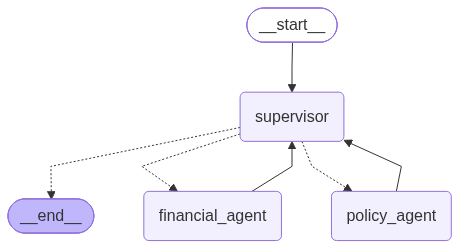

In [16]:
workdone

In [159]:
for step in workdone.stream(
    {"messages": [("user", "For L004, can I overpay 5000 without penalty, and what would my new monthly payment be?")]},
    config={"recursion_limit": 8}
):
    print(step)   # prints each node as it runs

{'supervisor': {'next_agent': 'policy_agent', 'loan_id': 'L004'}}
{'policy_agent': {'messages': [HumanMessage(content='For L004, can I overpay 5000 without penalty, and what would my new monthly payment be?', additional_kwargs={}, response_metadata={}, id='b316adde-7a77-46d5-bf62-73546f8901ad'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 306, 'total_tokens': 328, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c400bf5046', 'id': 'chatcmpl-EB6RZFddntNvAeNfYpKn2HLiZJ8kE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe8ad-13ae-7d91-b504-6cb9591c0c02-0', tool_calls=[{'name': '

In [160]:
for step in workdone.stream({"messages": [("user", "What's the outstanding balance on L001?")]}):
    print(step)

{'supervisor': {'next_agent': 'financial_agent', 'loan_id': 'L001'}}
{'financial_agent': {'messages': [HumanMessage(content="What's the outstanding balance on L001?", additional_kwargs={}, response_metadata={}, id='193e3a2f-b98c-4eb4-9fad-aec9719081d9'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking for the outstanding balance on a specific loan with ID "L001".\nI need to query the database to find this information.\nFirst, I should list the tables to understand the schema.\nThen, I will construct a SQL query to get the outstanding balance for loan L001.\nFinally, I will execute the query and return the result.\n\nLet\'s start by listing the tables.\n', 'tool_calls': [{'id': '9hx4nbd3a', 'function': {'arguments': '{}', 'name': 'sql_db_list_tables'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 1162, 'total_tokens': 1270, 'completion_time': 0.210558424, 'completion_tokens_details': {'reasoning_to

In [161]:
for step in workdone.stream({"messages": [("user", "For L003, is there a penalty for overpaying?")]}):
    print(step)

{'supervisor': {'next_agent': 'policy_agent', 'loan_id': 'L003'}}
{'policy_agent': {'messages': [HumanMessage(content='For L003, is there a penalty for overpaying?', additional_kwargs={}, response_metadata={}, id='1993589e-5cb5-4621-a8fc-5b80e58ec007'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 296, 'total_tokens': 321, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c400bf5046', 'id': 'chatcmpl-EB72o4J8PEzIplQ9aeD69PECK4YmR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe8d0-5227-7203-b94b-80643df51704-0', tool_calls=[{'name': 'retrieve_doc', 'args': {'query': 'penalty f

In [162]:
for step in workdone.stream({"messages": [("user", "What's the weather today?")]}):
    print(step)

{'supervisor': {'next_agent': 'FINISH', 'messages': [AIMessage(content="I'm unable to access real-time data, including current weather information. I recommend checking a reliable weather website or a weather app for the latest updates on today's weather.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 29, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_25b7d0bd77', 'id': 'chatcmpl-EB735roybEPJdXxFcYOgZXPsINK1U', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fe8d0-9594-7532-a452-37861c749161-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 29, 'output_tokens': 

In [27]:

grader_model=ChatOpenAI(model="gpt-4o-mini")

In [28]:
class PolicyResult(BaseModel):
    answer: str = Field(description="The answer to the policy question")
    cited_clause: str = Field(description="The specific clause relied on, e.g. 'Clause 4.1'")


class FinancialResult(BaseModel):
    answer: str = Field(description="The answer to the financial question")
    value: float | None = Field(
        default=None,
        description="The key numeric result if the answer contains one "
        "(e.g. a balance or monthly payment). Null if not applicable."
    )

class GradeResult(BaseModel):
    grade: Literal["sufficient", "insufficient"] = Field(
        description="'sufficient' if the answer clearly and unambiguously addresses "
        "the question; 'insufficient' if uncertain, declining, or missing information."
    )

class DocumentState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
    next_agent: str | None
    loan_id: str | None
    policy_result: PolicyResult | None
    financial_result: FinancialResult | None
    retrieval_grade: Literal["sufficient", "insufficient"] | None
    grade_attempts: int
    human_decision: str | None



In [38]:
def policy_node(state: DocumentState) -> dict:
    messages = state["messages"]

    # on retry, inject a multi-query instruction
    if state.get("grade_attempts", 0) > 0:
        retry_note = HumanMessage(content=
            "The previous attempt was graded insufficient. Decompose this question "
            "into 2-3 more specific sub-questions, search the document for each, and "
            "synthesize a more complete answer.")
        messages = messages + [retry_note]

    result = policy_agent.invoke({"messages": state["messages"]})
    agent_answer = result["messages"][-1].content

    structurer = policy_model.with_structured_output(PolicyResult)
    structured = structurer.invoke([
        HumanMessage(content=f"Extract the answer and cited clause from this response:\n{agent_answer}")
    ])

    return {
        "messages": result["messages"],
        "policy_result": structured,  
    }

#-----------------
# Retrival Grade
#----------------
GRADER_SYSTEM = """You judge whether a policy answer sufficiently addresses the user's
question. Return 'sufficient' only if the answer clearly and confidently answers the
question and is grounded in a cited clause. Return 'insufficient' if the answer is
uncertain, declines, states information is missing, or lacks a citation."""

def grader_node(state: DocumentState) -> dict:
    question = state["messages"][0].content
    pr = state["policy_result"]
    retrieved = f"Answer: {pr.answer}\nCited clause: {pr.cited_clause}"

    grader = grader_model.with_structured_output(GradeResult)
    result = grader.invoke([
        SystemMessage(content=GRADER_SYSTEM),
        HumanMessage(content=f"Question: {question}\n\n{retrieved}"),
    ])
    attempts = state.get("grade_attempts", 0) + 1
    return {"retrieval_grade": result.grade, "grade_attempts": attempts}

def next_grade(state: DocumentState) -> str:
    if state["retrieval_grade"] == "sufficient":
        return "supervisor"
    if state["grade_attempts"] >= 2:
        return "hitl"              # tried twice, escalate to human
    return "policy_agent"          # retry with multi-query
# ---------------------
## FINANCIAL NODE
#---------------------


def financial_node(state: DocumentState) -> dict:
    result = Financialagent.invoke({"messages": state["messages"]})
    agent_answer = result["messages"][-1].content

    structurer = financial_model.with_structured_output(FinancialResult)
    structured = structurer.invoke([
        HumanMessage(content=f"Extract the answer and the key numeric value from this response:\n{agent_answer}")
    ])

    return {
        "messages": result["messages"],
        "financial_result": structured,
    }


# ---------------------
## Human in the loop Node
#---------------------


def hitl_node(state: DocumentState) -> dict:
    proposed = state["policy_result"].answer
    decision = interrupt({
        "question": state["messages"][0].content,
        "proposed_answer": proposed,
        "reason": "Low confidence after 2 retrieval attempts — please review.",
    })

    if decision == "yes":
        final = AIMessage(content=(
            f"{proposed}\n\n"
            "_Note: this response was flagged as low-confidence by the system and "
            "approved after human review._"
        ))
    else:
        final = AIMessage(content=(
            "After review, this question couldn't be answered with confidence from the "
            "available loan documents, and the proposed response was not approved. "
            "Please rephrase your question, or contact a loan advisor for clarification "
            "on this specific matter."
        ))

    return {"human_decision": decision, "messages": [final]}

In [39]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import  HumanMessage, SystemMessage, AIMessage
from langgraph.types import interrupt,Command

checkpointer = InMemorySaver()

graph=StateGraph(DocumentState)

graph.add_node("supervisor",supervisor_node)
graph.add_node("policy_agent",policy_node)
graph.add_node("financial_agent",financial_node)
graph.add_node('grader_node',grader_node)
graph.add_node("hitl",hitl_node)

graph.add_edge(START, "supervisor")
graph.add_conditional_edges ("supervisor", route_next , {"financial_agent":"financial_agent",
                                                            "policy_agent":"policy_agent",
                                                            END:END} )


graph.add_edge("financial_agent","supervisor")
graph.add_edge("policy_agent","grader_node")
graph.add_conditional_edges("grader_node",next_grade,{
    "supervisor": "supervisor",
    "policy_agent": "policy_agent",
    "hitl": "hitl",
})
graph.add_edge("hitl", END)  

workdone= graph.compile(checkpointer=checkpointer)

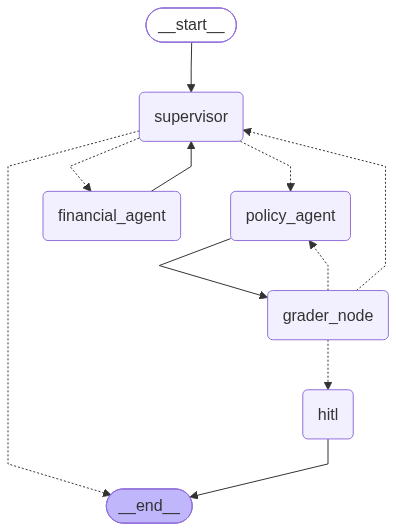

In [40]:
workdone

In [42]:
config = {"configurable": {"thread_id": "test-hitl-3"}}

result = workdone.invoke(
    {"messages": [("user", "For L003, what is the exact penalty amount in euros for breaking the lease clause?")],
     "grade_attempts": 0},
    config=config
)
print("Interrupted?", "__interrupt__" in result)
print(result.get("__interrupt__"))

Interrupted? True
[Interrupt(value={'question': 'For L003, what is the exact penalty amount in euros for breaking the lease clause?', 'proposed_answer': 'The retrieved clauses do not specifically mention a penalty related to breaking the lease clause.', 'reason': 'Low confidence after 2 retrieval attempts — please review.'}, id='97efe5513e82823cb4ac208b5b728514')]


In [43]:
from langgraph.types import Command

# resume the SAME thread with the human's answer
final = workdone.invoke(Command(resume="yes"), config=config)
print(final["messages"][-1].content)

The retrieved clauses do not specifically mention a penalty related to breaking the lease clause.

_Note: this response was flagged as low-confidence by the system and approved after human review._


In [47]:
config_no = {"configurable": {"thread_id": "test-hitl-no"}}
result = workdone.invoke(
     {"messages": [("user", "For L003, what is the exact euro penalty for converting from fixed to variable rate mid-term?")],
     "grade_attempts": 0},
    config=config_no
)
final = workdone.invoke(Command(resume="no"), config=config_no)
print(final["messages"][-1].content)

After review, this question couldn't be answered with confidence from the available loan documents, and the proposed response was not approved. Please rephrase your question, or contact a loan advisor for clarification on this specific matter.


In [48]:
config_no = {"configurable": {"thread_id": "test-no-2"}}
for step in workdone.stream(
    {"messages": [("user", "For L003, what is the exact euro penalty for converting from fixed to variable rate mid-term?")],
     "grade_attempts": 0},
    config=config_no
):
    print(list(step.keys()))

['supervisor']
['policy_agent']
['grader_node']
['policy_agent']
['grader_node']
['__interrupt__']


In [1]:
from langchain_mcp_adapters.client import MultiServerMCPClient

In [4]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient({
    "loan-tools": {
        "command": "python",
        "args": ["/Users/vatsal/Machine Learning/Gen AI/AIproject/src/Intelligent_agents/mcp_server/server.py"],
        "transport": "stdio",
    }
})

all_tools = await client.get_tools()      # async — pulls all 8 tools from the server

# split per agent (same division as before)
financial_tools = [t for t in all_tools if t.name in
    ("sql_db_list_tables", "sql_db_query",
     "monthly_payment", "lump_sum_recalc", "dti", "early_repayment_charge")]
policy_tools = [t for t in all_tools if t.name == "retrieve_doc"]



[StructuredTool(name='sql_db_list_tables', description='Input is an empty string, output is a comma-separated list of tables in the database.', args_schema={'properties': {}, 'title': 'sql_db_list_tablesArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x1068c3380>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x10695e520>),
 StructuredTool(name='sql_db_query', description='Input to this tool is a detailed and correct SQL query, output is a result from the database.\n    If the query is not correct, an error message will be returned.\n    If an error is returned, rewrite the query, check the query, and try again.', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'sql_db_queryArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x1068c3380>, response_format='content_and_artifact', coroutine=